In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
house_data = pd.read_csv('housing_price_dataset.csv')
house_data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81,USS Barnett\nFPO AP 44820
4,59982.20,5.04,7.84,4.23,26354.11,630943.49,USNS Raymond\nFPO AE 09386


In [38]:
# Droping the non-numeric column
house_data = house_data.drop(columns=['Address'])

In [39]:
X = house_data.drop(columns=['Price'])
y = house_data['Price']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
lasso = Lasso(max_iter=10000)
params = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]}
lasso_grid = GridSearchCV(lasso, param_grid=params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)

In [43]:
ridge = Ridge(max_iter=10000)
ridge_grid = GridSearchCV(ridge, param_grid=params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

In [44]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name} REGRESSION METRICS:")
    print(f"Best Alpha: {lasso_grid.best_params_['alpha'] if 'Lasso' in name else ridge_grid.best_params_['alpha']}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")
    return r2

r2_lasso = evaluate_model("Lasso (L1)", y_test, y_pred_lasso)
r2_ridge = evaluate_model("Ridge (L2)", y_test, y_pred_ridge)


📊 Lasso (L1) REGRESSION METRICS:
Best Alpha: 5
Mean Absolute Error (MAE): 80878.87
Mean Squared Error (MSE): 10088961676.59
Root Mean Squared Error (RMSE): 100443.82
R² Score: 0.9180

📊 Ridge (L2) REGRESSION METRICS:
Best Alpha: 1
Mean Absolute Error (MAE): 80877.76
Mean Squared Error (MSE): 10089003188.71
Root Mean Squared Error (RMSE): 100444.03
R² Score: 0.9180


In [45]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

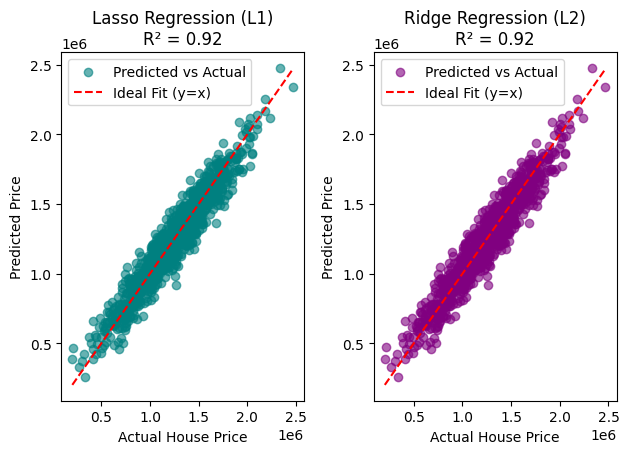

In [46]:
# Lasso
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lasso, alpha=0.6, color='teal', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit (y=x)')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted Price')
plt.title(f'Lasso Regression (L1)\nR² = {r2_lasso:.2f}')
plt.legend()

# Ridge
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_ridge, alpha=0.6, color='purple', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit (y=x)')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted Price')
plt.title(f'Ridge Regression (L2)\nR² = {r2_ridge:.2f}')
plt.legend()

plt.tight_layout()
plt.show()